In [2]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [5]:
import math
import plotly.express as px
import datetime as dt
import pandas as pd
from lunarcalendar import Converter, Solar, Lunar, DateNotExist
from pandas_profiling import ProfileReport
pd.set_option('max_columns', 200000000000000)

In [7]:
# !pip3 -q install plotly
# !pip3 -q install lunarcalendar
# !pip3 -q install pandas_profiling
# !pip3 -q install statsmodels
# !pip3 -q install pmdarima
# !pip3 -q install pandas


In [8]:
# pd.set_option('display.max_rows', 500)
# pd.set_option('display.max_columns', 500)
# pd.set_option('display.width', 1000)

#### Read Data

In [9]:
revenue = pd.read_csv("data/DT.csv",
                      encoding='latin-1', sep = "\t")

In [10]:
revenue.columns = ["soluonghoadon", "soluongkhach", "doanhso",
                   "doanhthu", "giamgiamon", "giamgiahoadon",
                   "giamgiathanhvien", "vat", "phuphi", 
                   "macuahang", "tencuahang", "ngay" ]

In [11]:
# profile = ProfileReport(revenue, title="Pandas Profiling Report")
# profile

In [12]:
revenue = revenue[["macuahang", "tencuahang", "ngay", "soluonghoadon",
                   "soluongkhach", "doanhso", "giamgiamon", "giamgiahoadon",
                   "giamgiathanhvien", "vat", "phuphi", "doanhthu"]]

In [13]:
revenue["ngay"] = pd.to_datetime(revenue['ngay'], format="%d/%m/%Y")

revenue["dow"] = revenue["ngay"].dt.dayofweek

In [14]:
ungvankhiem = revenue.loc[revenue.macuahang == 1]


In [15]:
# ax =  ungvankhiem['doanhso'].plot.line(title = 'Monthly Sales Timeseries Analysis', legend =True, table = False, grid = False, subplots = False,  figsize =(15,8), colormap = 'Accent', fontsize = 15,linestyle='-', stacked=False)
# #Configure x and y labels:
# plt.ylabel('Volume of sales',horizontalalignment="center",fontstyle = "normal", fontsize = "large", fontfamily = "sans-serif")
# plt.xlabel('Year & Quarter',horizontalalignment="center",fontstyle = "normal", fontsize = "large", fontfamily = "sans-serif")
# #Set up title, legends and theme:
# plt.title('Monthly Sales Timeseries Analysis \n',horizontalalignment="center", fontstyle = "normal", fontsize = "22", fontfamily = "sans-serif")
# plt.legend(loc='upper left', fontsize = "medium")
# plt.xticks(rotation=0, horizontalalignment="center")
# plt.yticks(rotation=0, horizontalalignment="right")
# plt.style.use(['classic'])
# ax.autoscale(enable=True, axis='x', tight=False)

In [16]:
ungvankhiem.tail()

,macuahang,tencuahang,ngay,soluonghoadon,soluongkhach,doanhso,giamgiamon,giamgiahoadon,giamgiathanhvien,vat,phuphi,doanhthu,dow
17959,1,ICool Ung V?n Khiêm,2020-10-08,74,584,107686900.0,4263470.0,624880.0,234636.5,380684.5,0,102563913.5,3
17976,1,ICool Ung V?n Khiêm,2020-10-09,77,592,123594500.0,6061680.0,511600.0,27700.0,407789.0,0,116993520.0,4
17993,1,ICool Ung V?n Khiêm,2020-10-10,129,992,232402201.0,12150970.0,1271630.0,369430.0,205529.5,0,218610171.0,5
18010,1,ICool Ung V?n Khiêm,2020-10-11,78,578,119991200.0,4417660.0,2148050.0,0.0,0.0,0,113425490.0,6
18027,1,ICool Ung V?n Khiêm,2020-10-12,64,466,94044900.0,6736700.0,368930.0,0.0,689626.0,0,86939270.0,0


## calculate RMSE, MSE, MAE - Accounting method

In [17]:
ungvankhiem[ungvankhiem['ngay']>='2020-01-01']

,macuahang,tencuahang,ngay,soluonghoadon,soluongkhach,doanhso,giamgiamon,giamgiahoadon,giamgiathanhvien,vat,phuphi,doanhthu,dow
14165,1,ICool Ung V?n Khiêm,2020-01-01,126,877,204014960.0,1732000.0,2319060.0,0.0,36100.0,0,199963900.0,2
14182,1,ICool Ung V?n Khiêm,2020-01-02,57,448,93051200.0,249000.0,730010.0,151200.0,291550.0,0,91920990.0,3
14199,1,ICool Ung V?n Khiêm,2020-01-03,86,631,148580300.0,1284000.0,2248570.0,751725.0,757582.5,0,144296005.0,4
14216,1,ICool Ung V?n Khiêm,2020-01-04,95,710,184427802.0,1339000.0,2835910.1,308210.0,1066552.5,100000,179944681.9,5
14233,1,ICool Ung V?n Khiêm,2020-01-05,90,677,154546300.0,539000.0,775490.0,191350.0,401930.0,0,153040460.0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17959,1,ICool Ung V?n Khiêm,2020-10-08,74,584,107686900.0,4263470.0,624880.0,234636.5,380684.5,0,102563913.5,3
17976,1,ICool Ung V?n Khiêm,2020-10-09,77,592,123594500.0,6061680.0,511600.0,27700.0,407789.0,0,116993520.0,4
17993,1,ICool Ung V?n Khiêm,2020-10-10,129,992,232402201.0,12150970.0,1271630.0,369430.0,205529.5,0,218610171.0,5
18010,1,ICool Ung V?n Khiêm,2020-10-11,78,578,119991200.0,4417660.0,2148050.0,0.0,0.0,0,113425490.0,6


In [18]:
rev1 = ungvankhiem[['ngay', 'doanhthu']]

In [19]:
month=rev1[rev1['ngay']>='2019-01-01' ][rev1['ngay']<'2019-02-01'].reset_index(drop=True, inplace=False)

<ipython-input-19-57401662f5d5>:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  month=rev1[rev1['ngay']>='2019-01-01' ][rev1['ngay']<'2019-02-01'].reset_index(drop=True, inplace=False)


In [20]:
month


,ngay,doanhthu
0,2019-01-01,171689657.0
1,2019-01-02,92862030.0
2,2019-01-03,95149550.0
3,2019-01-04,113302488.0
4,2019-01-05,187263056.0
5,2019-01-06,160604201.0
6,2019-01-07,63664370.0
7,2019-01-08,94472462.0
8,2019-01-09,82912925.0
9,2019-01-10,116323185.0


In [21]:
month['doanhthu'].sum()

4364664735.0

In [22]:
## calculate revenue of the specified month
def rev_month(tab, start, end):
    month=tab[tab['ngay']>=start ][tab['ngay']<end].reset_index(drop=True, inplace=False)
    
    return month['doanhthu'].sum()

In [23]:
## 2019-01
start='2019-01-01'
end  ='2019-02-01'
rev_month(ungvankhiem, start, end)

<ipython-input-22-fa64c4ae0d4c>:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  month=tab[tab['ngay']>=start ][tab['ngay']<end].reset_index(drop=True, inplace=False)


4364664735.0

In [24]:
def rev_m_tmp(t, year, ungvankhiem):
    ## 2019-01
    if t<=8:
        start=str(year)+'-0{}-01'.format(t)
        end  =str(year)+'-0{}-01'.format(str(t+1))
    if t==9:
        start=str(year)+'-09-01'
        end  =str(year)+'-10-01'
        
    if t>9 and t<12:
        start=str(year)+'-{}-01'.format(t)
        end  =str(year)+'-{}-01'.format(str(t+1))
    if t==12:
        start=str(year)+'-12-01'
        end  =str(year+1)+'-01-01'
        
    return rev_month(ungvankhiem, start, end)

In [25]:
year=2019
rev_real_2019=[]
for i in range(1, 13):
    print("Month: ", i)
    x=rev_m_tmp(i, year, ungvankhiem)
    print(x)
    rev_real_2019.append(x)
   

Month:  1
4364664735.0
Month:  2
2377125776.8
Month:  3
3519695802.8
Month:  4
3421046358.9
Month:  5
3656996576.3
Month:  6
4008110068.0
Month:  7
4001986909.0
Month:  8
4197568177.35
Month:  9
3731670226.0
Month:  10
4067642173.9
Month:  11
3805006263.0
Month:  12
4031090902.0


<ipython-input-22-fa64c4ae0d4c>:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  month=tab[tab['ngay']>=start ][tab['ngay']<end].reset_index(drop=True, inplace=False)


In [26]:
year=2020
rev_real_2020=[]

for i in range(1, 10):
    print("Month: ", i)
    x=rev_m_tmp(i, year, ungvankhiem)
    print(x)
    rev_real_2020.append(x)
    
   

Month:  1
3557940409.9
Month:  2
2636426932.0
Month:  3
1218659972.0
Month:  4
8112100.0
Month:  5
77340310.0
Month:  6
2605775346.0
Month:  7
3702470433.0
Month:  8
3122499933.5
Month:  9
3461183841.4


<ipython-input-22-fa64c4ae0d4c>:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  month=tab[tab['ngay']>=start ][tab['ngay']<end].reset_index(drop=True, inplace=False)


#### just get data from 01-2019 --> 09-2020 to calculate MSE, MAE

In [27]:
## accounting predicted values 2019
predicted='4100000000,,3000000000,,4230619240,,4149371434,,4253046306,,3950000000,,4200000000,,4200000000,,4230000000,,4246000000,,4200000000,,4436000000'.split(',,')
predicted_2019=[float(x) for x in predicted ]
predicted_2019

[4100000000.0,
 3000000000.0,
 4230619240.0,
 4149371434.0,
 4253046306.0,
 3950000000.0,
 4200000000.0,
 4200000000.0,
 4230000000.0,
 4246000000.0,
 4200000000.0,
 4436000000.0]

In [28]:
## accounting predicted values 2020 : M01-> M09 ## removed M10, M11, M12 = 4941090000, 4953375000, 5173823000
predicted = '3750000000,,3775800000,,4253200000,,4244625000,,4386113000,,4244625000,,4611250000,,4611250000,,4709880000'.split(",,")
predicted_2020=[float(x) for x in predicted ]
predicted_2020

[3750000000.0,
 3775800000.0,
 4253200000.0,
 4244625000.0,
 4386113000.0,
 4244625000.0,
 4611250000.0,
 4611250000.0,
 4709880000.0]

In [29]:
len(predicted_2019), len(predicted_2020)

(12, 9)

In [30]:
## calculate MSE: unit is 1K - divide from 1000000
tmp=[]
MAE_tmp=[]
for i in range(12):
    x=((rev_real_2019[i]-predicted_2019[i])/1000000)**2
    print("Month: ", str(i+1),"\t| (Predicted rev - real rev)^2 = ", str(x))
    tmp.append(x)
    MAE_tmp.append((abs(rev_real_2019[i]-predicted_2019[i])/1000000))

Month:  1 	| (Predicted rev - real rev)^2 =  70047.42195262024
Month:  2 	| (Predicted rev - real rev)^2 =  387972.29792700324
Month:  3 	| (Predicted rev - real rev)^2 =  505412.13356026215
Month:  4 	| (Predicted rev - real rev)^2 =  530457.4150194206
Month:  5 	| (Predicted rev - real rev)^2 =  355275.28027544287
Month:  6 	| (Predicted rev - real rev)^2 =  3376.7800029646237
Month:  7 	| (Predicted rev - real rev)^2 =  39209.18420737428
Month:  8 	| (Predicted rev - real rev)^2 =  5.9137614010534865
Month:  9 	| (Predicted rev - real rev)^2 =  248332.56365489107
Month:  10 	| (Predicted rev - real rev)^2 =  31811.514131117805
Month:  11 	| (Predicted rev - real rev)^2 =  156020.05226922518
Month:  12 	| (Predicted rev - real rev)^2 =  163951.3776431736


In [31]:
MSE=1/12*(sum(tmp))
print("MSE = ", MSE)

MSE =  207655.99453374132


In [32]:
print("RMSE = ", math.sqrt(MSE))

RMSE =  455.69287303373676


In [33]:
print("MAE = ", 1/12*sum(MAE_tmp))

MAE =  388.1652180791665


## data visualization

In [34]:
revenue[revenue.macuahang==1].sort_values("ngay", ascending=False).head()

,macuahang,tencuahang,ngay,soluonghoadon,soluongkhach,doanhso,giamgiamon,giamgiahoadon,giamgiathanhvien,vat,phuphi,doanhthu,dow
18027,1,ICool Ung V?n Khiêm,2020-10-12,64,466,94044900.0,6736700.0,368930.0,0.0,689626.0,0,86939270.0,0
18010,1,ICool Ung V?n Khiêm,2020-10-11,78,578,119991200.0,4417660.0,2148050.0,0.0,0.0,0,113425490.0,6
17993,1,ICool Ung V?n Khiêm,2020-10-10,129,992,232402201.0,12150970.0,1271630.0,369430.0,205529.5,0,218610171.0,5
17976,1,ICool Ung V?n Khiêm,2020-10-09,77,592,123594500.0,6061680.0,511600.0,27700.0,407789.0,0,116993520.0,4
17959,1,ICool Ung V?n Khiêm,2020-10-08,74,584,107686900.0,4263470.0,624880.0,234636.5,380684.5,0,102563913.5,3


In [35]:
fig = px.line(revenue, x="ngay", y="doanhso", color ="macuahang")
fig.show()

In [37]:
for ch in list(set((revenue["macuahang"].tolist()))):
    if ch not in [1, 4, 5, 6, 16, 18, 19]:
        print("===== ===== =====")
        print("Store: ", ch)
        if ch==2:
            print("==> this store will be remove because of closed store")
#         px.line(revenue[revenue.macuahang == ch], x="ngay", y="doanhso", color ="macuahang").show()


===== ===== =====
Store:  2
==> this store will be remove because of closed store
===== ===== =====
Store:  7
===== ===== =====
Store:  9
===== ===== =====
Store:  10
===== ===== =====
Store:  11
===== ===== =====
Store:  12
===== ===== =====
Store:  13
===== ===== =====
Store:  14
===== ===== =====
Store:  17
===== ===== =====
Store:  22
===== ===== =====
Store:  23


In [38]:

def convert_holiday(date):
    year = date.year
    if date == dt.datetime(year, 4, 30):
        return "holiday"
    if date == dt.datetime(year, 10, 20):
        return 

In [39]:
import datetime
from lunarcalendar import Converter, Solar, Lunar, DateNotExist

l = Lunar(year=2019, month=1, day=1)
print(Converter.Lunar2Solar(l))

Solar(year=2019, month=2, day=5)


In [40]:
revenue.ngay.apply(convert_holiday)

0        None
1        None
2        None
3        None
4        None
         ... 
18038    None
18039    None
18040    None
18041    None
18042    None
Name: ngay, Length: 18043, dtype: object

In [41]:
revenue.sort_values("ngay", ascending=False).head()

,macuahang,tencuahang,ngay,soluonghoadon,soluongkhach,doanhso,giamgiamon,giamgiahoadon,giamgiathanhvien,vat,phuphi,doanhthu,dow
18042,9,ICool Nguy?n S?n,2020-10-12,19,90,15823600.0,629440.0,227540.0,0.0,0.0,0,14966620.0,0
18034,18,ICool Tr?n Não,2020-10-12,55,419,75629401.0,1878000.0,94940.1,85600.0,325305.0,0,73570860.9,0
18027,1,ICool Ung V?n Khiêm,2020-10-12,64,466,94044900.0,6736700.0,368930.0,0.0,689626.0,0,86939270.0,0
18028,10,ICool Thành Thái,2020-10-12,52,293,68070200.0,2184920.0,110350.0,67260.0,164995.0,0,65707670.0,0
18029,11,ICool Nguy?n Trãi,2020-10-12,10,58,10847500.0,314540.0,22540.0,0.0,0.0,0,10510420.0,0


### Time series with auto_arima algorithm

###### ARIMA (AutoRegressive Integrated Moving Average)

- In this algo, we have 3 things to learn: seasonality, trend, noise -> p,d,q
    - p: auto-regressive aspect -> p shows that the data in the past will aspect the trend in the past to predict the future
    - d: integrated part        -> d maintains stability of the trend from the past to future
    - q: moving average part
    

In [42]:
CH1=revenue[revenue.macuahang == 1][['doanhso', 'ngay']]
CH1.head()

,doanhso,ngay
0,86496200.0,2017-07-25
7,95504100.0,2017-07-26
14,96707700.0,2017-07-27
21,128260700.0,2017-07-28
28,158043700.0,2017-07-29


In [43]:
CH1['ngay']

0       2017-07-25
7       2017-07-26
14      2017-07-27
21      2017-07-28
28      2017-07-29
           ...    
17959   2020-10-08
17976   2020-10-09
17993   2020-10-10
18010   2020-10-11
18027   2020-10-12
Name: ngay, Length: 1154, dtype: datetime64[ns]

In [44]:
CH1.index=CH1['ngay']
del CH1['ngay']

In [45]:
CH1.head()

,doanhso
ngay,
2017-07-25,86496200.0
2017-07-26,95504100.0
2017-07-27,96707700.0
2017-07-28,128260700.0
2017-07-29,158043700.0


In [46]:
CH1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1154 entries, 2017-07-25 to 2020-10-12
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   doanhso  1154 non-null   float64
dtypes: float64(1)
memory usage: 18.0 KB


In [47]:
import matplotlib.pyplot as plt

In [48]:
px.line(revenue[revenue.macuahang == 1], x="ngay", y="doanhso", color ="macuahang").show()

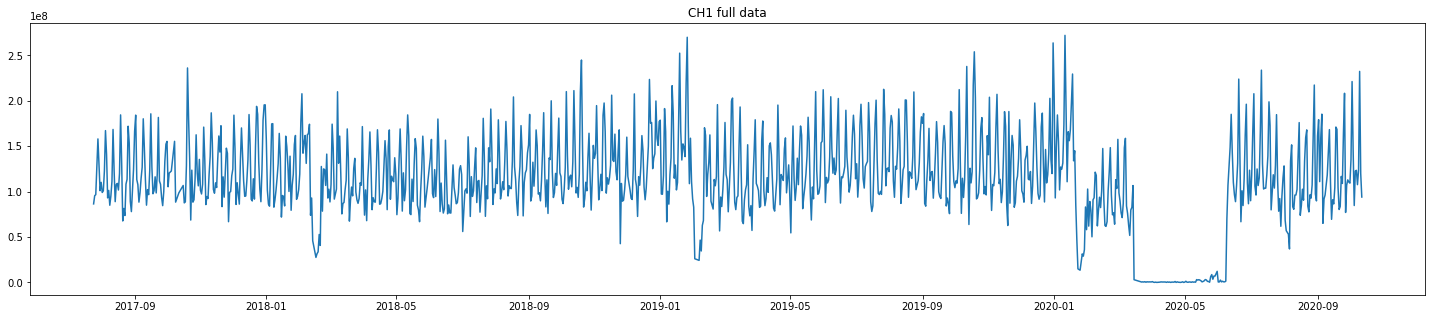

In [49]:
plt.figure(figsize=(25,5))
plt.plot(CH1)
plt.title("{} full data".format('CH1'))
plt.show()

In [50]:
data_train=CH1[CH1.index < '2020-03-15']

# plt.figure(figsize=(25*data_train.shape[0]/CH1.shape[0],5))
# plt.plot(data_train)
# plt.title("train data")
# plt.show()

In [51]:
data_train.shape

(951, 1)

In [52]:
data_train.sort_index(inplace=True)

<ipython-input-53-51e5b7c9d5d2>:2: FutureWarning:

the 'freq'' keyword is deprecated, use 'period' instead



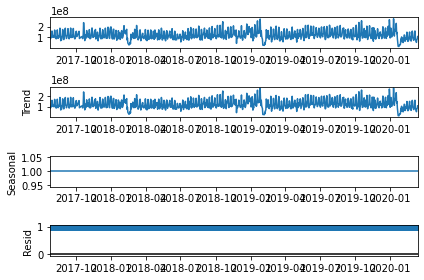

In [53]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(data_train, model='multiplicative', freq=1).plot()



<ipython-input-54-9d5a263f8ac2>:1: FutureWarning:

the 'freq'' keyword is deprecated, use 'period' instead



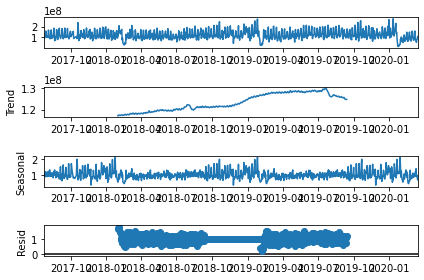

In [54]:
result = seasonal_decompose(data_train, model='multiplicative', freq=365).plot()

<ipython-input-55-09481cc2924c>:1: FutureWarning:

the 'freq'' keyword is deprecated, use 'period' instead



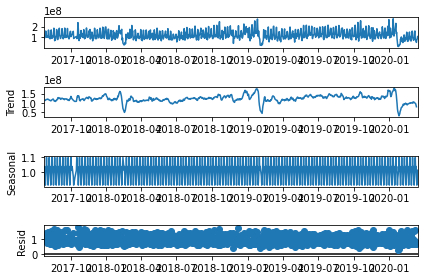

In [55]:
result = seasonal_decompose(data_train, model='multiplicative', freq=7).plot()

----- ----- ----- ----- ----- ----- ----- ----- ----- ----- ----- ----- ----- 

----- ----- ----- ----- ----- ----- ----- ----- ----- ----- ----- ----- ----- 

----- ----- ----- ----- ----- ----- ----- ----- ----- ----- ----- ----- ----- 

In [56]:
train.head()

NameError: name 'train' is not defined

In [57]:
new_train=train.reset_index()

NameError: name 'train' is not defined

In [199]:
new_train.columns=['Datetime', 'doanhthu']
new_train.head()


,Datetime,doanhthu
0,2017-07-25,86496200.0
1,2017-07-26,95504100.0
2,2017-07-27,96707700.0
3,2017-07-28,128260700.0
4,2017-07-29,158043700.0


In [200]:
new_train.Timestamp = pd.to_datetime(new_train.Datetime,format='%d-%m-%Y')
new_train.index=new_train.Timestamp
new_train=new_train[['doanhthu']]

<ipython-input-200-92a027719c04>:1: UserWarning:

Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access



In [201]:
new_train.head()

,doanhthu
Datetime,
2017-07-25,86496200.0
2017-07-26,95504100.0
2017-07-27,96707700.0
2017-07-28,128260700.0
2017-07-29,158043700.0


In [202]:
new_train.sort_index(inplace=True)

In [203]:
new_train.head()

,doanhthu
Datetime,
2017-07-25,86496200.0
2017-07-26,95504100.0
2017-07-27,96707700.0
2017-07-28,128260700.0
2017-07-29,158043700.0


<ipython-input-206-174c7515e78c>:2: FutureWarning:

the 'freq'' keyword is deprecated, use 'period' instead



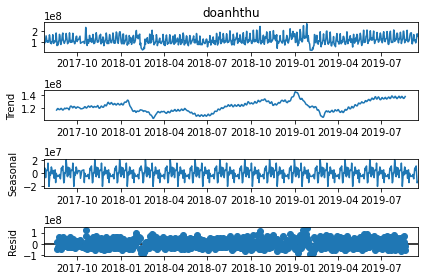

In [206]:
import statsmodels.api as sm 
sm.tsa.seasonal_decompose(new_train['doanhthu'], freq = 52).plot() 
result = sm.tsa.stattools.adfuller(new_train.doanhthu)
plt.show()

#### traning

In [58]:
from pmdarima.arima import auto_arima

stepwise_model = auto_arima(CH1, 
                            start_p=2,
                            start_q=2,
                            max_p=5,
                            max_q=5,
                            m=12,
                            start_P=1, 
                            seasonal=True,
                            d=1, 
                            D=1,
                            trace=True,
                            error_action='ignore',  
                            suppress_warnings=True, 
                            stepwise=True)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=inf, Time=5.85 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=44208.557, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=43864.927, Time=0.55 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=1.00 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=44205.865, Time=0.11 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=43699.263, Time=1.41 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=3.63 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=1.47 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=43536.804, Time=1.23 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=43799.567, Time=0.43 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=inf, Time=3.58 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=inf, Time=1.20 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=43642.520, Time=2.89 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=43558.994, Time=4.37 sec
 ARIMA(0,1,0)(2,1,0)[12] intercept   : AI

In [59]:
print(stepwise_model.aic())

43536.80379648066


In [60]:
# train = CH1.loc[:'2020-03-15']
# test = CH1.loc['2020-06-14':]

train = CH1.loc[:'2019-09-15']
test = CH1.loc['2019-09-15':'2020-03-15']

In [61]:
test.head()


,doanhso
ngay,
2019-09-15,154138000.0
2019-09-16,99891903.0
2019-09-17,94574400.0
2019-09-18,92468600.0
2019-09-19,122500600.0


In [62]:
test.shape


(182, 1)

In [63]:
train.shape

(771, 1)

In [64]:
stepwise_model.fit(train)


ARIMA(order=(0, 1, 0), scoring_args={}, seasonal_order=(2, 1, 0, 12),
      suppress_warnings=True, with_intercept=False)

In [65]:
future_forecast = stepwise_model.predict(n_periods=len(test))


In [66]:
future_forecast

array([1.45703651e+08, 1.44760531e+08, 1.29674601e+08, 1.37042626e+08,
       1.28427000e+08, 1.65034112e+08, 1.71645873e+08, 1.55904019e+08,
       1.38809375e+08, 1.55001550e+08, 1.64852614e+08, 1.24412011e+08,
       1.32696045e+08, 1.74199875e+08, 1.41800842e+08, 1.43168050e+08,
       1.24254151e+08, 1.37187702e+08, 1.47642034e+08, 1.49872776e+08,
       1.60975215e+08, 1.70658135e+08, 1.89402612e+08, 1.28334185e+08,
       1.25937117e+08, 1.47385387e+08, 1.45317169e+08, 1.63927049e+08,
       1.31111695e+08, 1.50182497e+08, 1.55090296e+08, 1.36992339e+08,
       1.43137504e+08, 1.63334171e+08, 1.86412157e+08, 1.49521004e+08,
       1.48002245e+08, 1.66105663e+08, 1.47918503e+08, 1.55629683e+08,
       1.38438598e+08, 1.63359346e+08, 1.70909162e+08, 1.60737684e+08,
       1.58058160e+08, 1.72896863e+08, 1.88537060e+08, 1.41881234e+08,
       1.44494186e+08, 1.74297310e+08, 1.55131368e+08, 1.63655768e+08,
       1.40412306e+08, 1.57943394e+08, 1.65913421e+08, 1.58668706e+08,
      

In [67]:
future_forecast = pd.DataFrame(future_forecast,index = test.index,columns=['Prediction'])


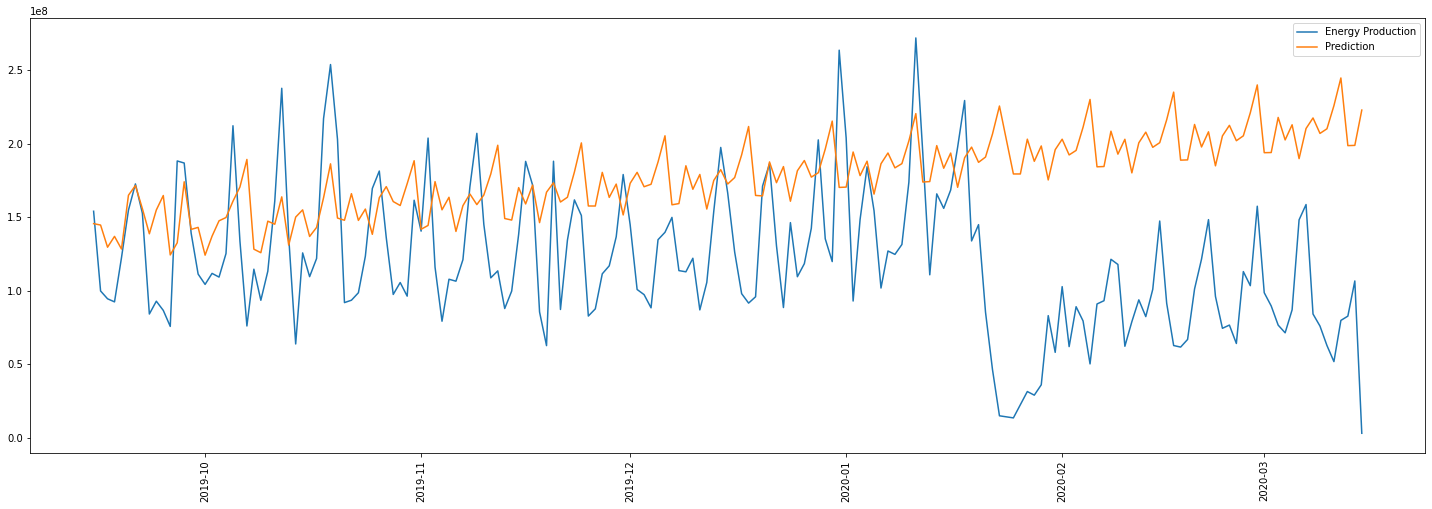

In [68]:
plt.figure(figsize=(25,8))
plt.plot(test, label='Energy Production')
plt.plot(future_forecast, label='Prediction')
plt.xticks(rotation='vertical')
plt.legend()
plt.show()

In [69]:
## remove trending: 
## link: https://machinelearningmastery.com/time-series-trends-in-python/

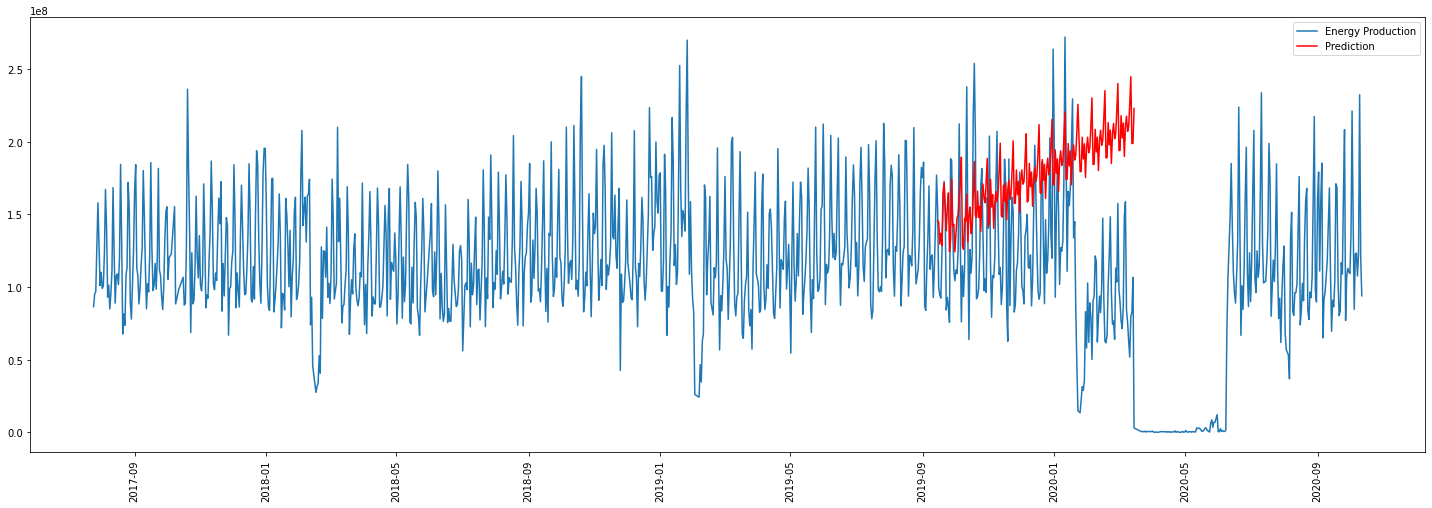

In [70]:
plt.figure(figsize=(25,8))
plt.plot(CH1, label='Energy Production')
plt.plot(future_forecast, label='Prediction', color='red')
plt.xticks(rotation='vertical')
plt.legend()
plt.show()

#### predict next 12 months


In [71]:
future_forecast = stepwise_model.predict(n_periods=len(test)+12)
future_forecast

array([1.45703651e+08, 1.44760531e+08, 1.29674601e+08, 1.37042626e+08,
       1.28427000e+08, 1.65034112e+08, 1.71645873e+08, 1.55904019e+08,
       1.38809375e+08, 1.55001550e+08, 1.64852614e+08, 1.24412011e+08,
       1.32696045e+08, 1.74199875e+08, 1.41800842e+08, 1.43168050e+08,
       1.24254151e+08, 1.37187702e+08, 1.47642034e+08, 1.49872776e+08,
       1.60975215e+08, 1.70658135e+08, 1.89402612e+08, 1.28334185e+08,
       1.25937117e+08, 1.47385387e+08, 1.45317169e+08, 1.63927049e+08,
       1.31111695e+08, 1.50182497e+08, 1.55090296e+08, 1.36992339e+08,
       1.43137504e+08, 1.63334171e+08, 1.86412157e+08, 1.49521004e+08,
       1.48002245e+08, 1.66105663e+08, 1.47918503e+08, 1.55629683e+08,
       1.38438598e+08, 1.63359346e+08, 1.70909162e+08, 1.60737684e+08,
       1.58058160e+08, 1.72896863e+08, 1.88537060e+08, 1.41881234e+08,
       1.44494186e+08, 1.74297310e+08, 1.55131368e+08, 1.63655768e+08,
       1.40412306e+08, 1.57943394e+08, 1.65913421e+08, 1.58668706e+08,
      

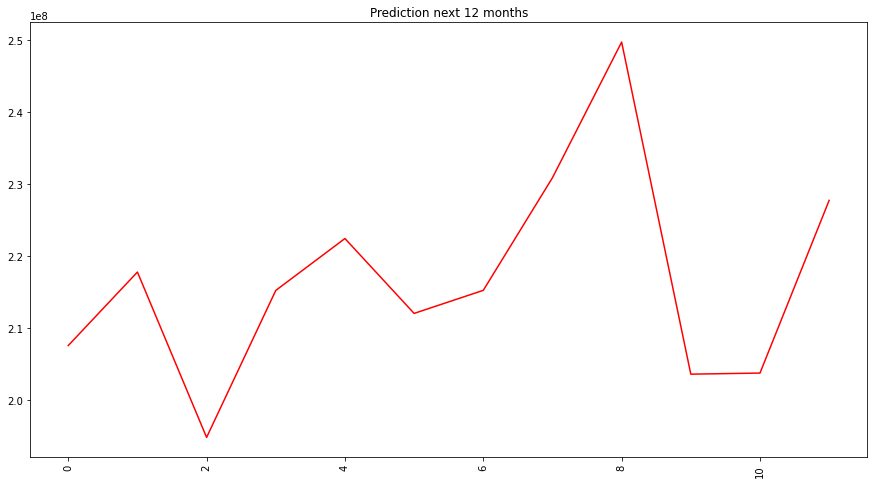

In [72]:
plt.figure(figsize=(15,8))
plt.plot(future_forecast[len(test):], color='red')
plt.xticks(rotation='vertical')
plt.title("Prediction next 12 months")
plt.show()

In [73]:
# # can tao them 12 index
# future_forecast = pd.DataFrame(future_forecast,index = test.index,columns=['Prediction'])
# plt.figure(figsize=(15,8))
# plt.plot(data_1985, label='Energy Production')
# plt.plot(future_forecast, label='Prediction', color='red')
# plt.xticks(rotation='vertical')
# plt.legend()
# plt.show()

In [74]:
from datetime import datetime
from dateutil.relativedelta import relativedelta
start = test.index[43]
start

Timestamp('2019-10-28 00:00:00')

In [75]:
date_after_month = start+ relativedelta(months=1)
date_after_month

Timestamp('2019-11-28 00:00:00')

In [76]:
def create_month(start, months):
    list_months = [start+ relativedelta(months=1)]
    i = 1
    while i<months:
        list_months.append(list_months[-1]+relativedelta(months=1))
        i+=1
    return list_months

In [77]:
months = create_month(start, 12)
months


[Timestamp('2019-11-28 00:00:00'),
 Timestamp('2019-12-28 00:00:00'),
 Timestamp('2020-01-28 00:00:00'),
 Timestamp('2020-02-28 00:00:00'),
 Timestamp('2020-03-28 00:00:00'),
 Timestamp('2020-04-28 00:00:00'),
 Timestamp('2020-05-28 00:00:00'),
 Timestamp('2020-06-28 00:00:00'),
 Timestamp('2020-07-28 00:00:00'),
 Timestamp('2020-08-28 00:00:00'),
 Timestamp('2020-09-28 00:00:00'),
 Timestamp('2020-10-28 00:00:00')]

In [78]:
new = {'ngay': months, 'doanhso': future_forecast[len(test):]}
new


{'ngay': [Timestamp('2019-11-28 00:00:00'),
  Timestamp('2019-12-28 00:00:00'),
  Timestamp('2020-01-28 00:00:00'),
  Timestamp('2020-02-28 00:00:00'),
  Timestamp('2020-03-28 00:00:00'),
  Timestamp('2020-04-28 00:00:00'),
  Timestamp('2020-05-28 00:00:00'),
  Timestamp('2020-06-28 00:00:00'),
  Timestamp('2020-07-28 00:00:00'),
  Timestamp('2020-08-28 00:00:00'),
  Timestamp('2020-09-28 00:00:00'),
  Timestamp('2020-10-28 00:00:00')],
 'doanhso': array([2.07550253e+08, 2.17773460e+08, 1.94779204e+08, 2.15218407e+08,
        2.22437455e+08, 2.12024369e+08, 2.15229836e+08, 2.30888848e+08,
        2.49756543e+08, 2.03574584e+08, 2.03725855e+08, 2.27745396e+08])}

In [79]:
df = pd.DataFrame(new)
df

,ngay,doanhso
0,2019-11-28,2.075503e+08
1,2019-12-28,2.177735e+08
2,2020-01-28,1.947792e+08
3,2020-02-28,2.152184e+08
4,2020-03-28,2.224375e+08
5,2020-04-28,2.120244e+08
6,2020-05-28,2.152298e+08
7,2020-06-28,2.308888e+08
8,2020-07-28,2.497565e+08
9,2020-08-28,2.035746e+08


In [80]:
import numpy as np

In [81]:
## remove trend
data_train=CH1[CH1.index <  '2020-03-15']
data_valid=CH1[CH1.index >= '2020-03-15']

train_log = np.log(data_train['doanhso'])
valid_log = np.log(data_valid['doanhso'])



/Library/Python/3.8/site-packages/pandas/core/series.py:726: RuntimeWarning:

divide by zero encountered in log



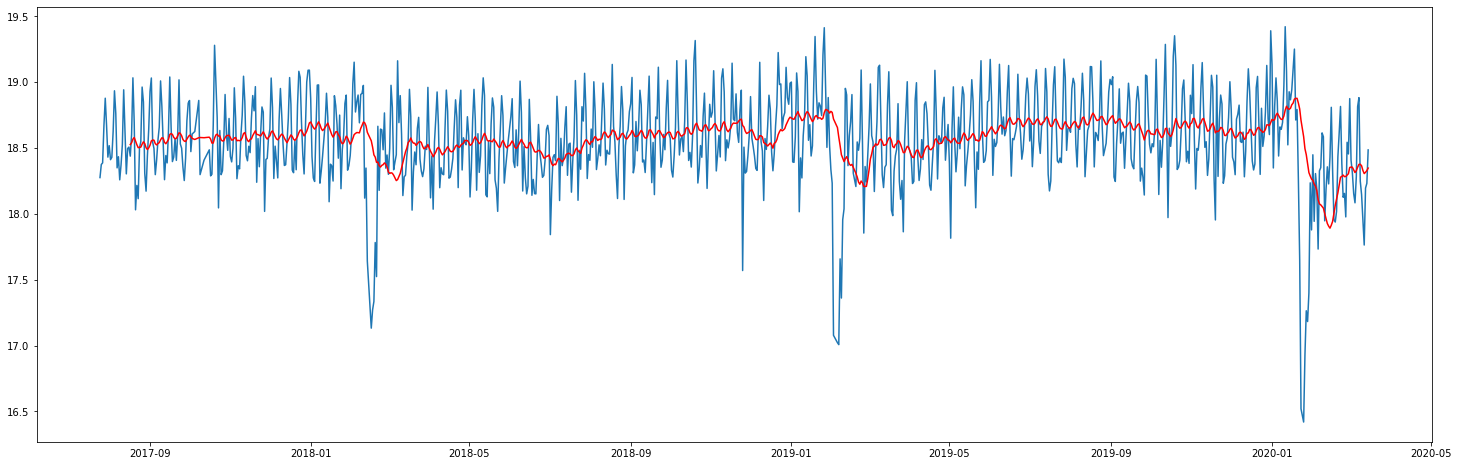

NameError: name 'train_log_moving_avg_diff' is not defined

In [82]:
moving_avg = train_log.rolling(24).mean()
plt.figure(figsize=(25,8))


plt.plot(train_log)
plt.plot(moving_avg, color = "red")
plt.show()


train_log_moving_avg_diff# ts_log.rolling(12).mean()

In [ ]:
train_log_moving_avg_diff = train_log - moving_avg
train_log_moving_avg_diff.dropna(inplace=True)

In [ ]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries):
    ## determining rolling statistics
    rolmean = data_train['doanhso'].rolling(24).mean()
    rolstd  = data_train['doanhso'].rolling(24).std()
    
    ## plot rolling statistics
    orig = plt.plot(timeseries, color='blue', label = 'Original')
    mean = plt.plot(rolmean,    color='red',  label = 'Rolling mean')
    std  = plt.plot(rolstd,     color='black',label = 'Rolling Std')
    
    plt.legend(loc='best')
    plt.title("Rolling mean and Standard deviation")
    plt.show(block=False)
    
    ## perform Dickey-Fuller Test
    print("Dickey-Fuller Test")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "P-value", "#Lags Used", "Number of Observations Used"])
    
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
        
    print(dfoutput)
    
    
from matplotlib.pylab import rcParams
rcParams['figure.figsize']=20,10




In [ ]:
test_stationarity(data_train['doanhso'])

In [ ]:
test_stationarity(train_log_moving_avg_diff)

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
decomposition = seasonal_decompose(pd.DataFrame(train_log).count().values, freq = 1)

In [ ]:
pd.DataFrame(train_log).count().values

In [ ]:
plt.figure(figsize=(25,8))
plt.plot(CH1, label='doanhso')
plt.plot(df.ngay, df['doanhso'], label='Prediction', color='red')
plt.xticks(rotation='vertical')
plt.legend()
plt.show()

## visualization weather data

In [ ]:
weather= pd.read_csv('/Volumes/GVO/SPACE/revenue_prediction/Document_Giang/data/hwd_order_491/weather_data_24hr.csv')

In [ ]:
weather["date"] = pd.to_datetime(weather["date"], format="%Y/%m/%d")

In [ ]:
type(weather['date'][1])

In [ ]:
weather['date'][1]

In [ ]:
weather.head()

#### our data is just focus from 2017-07-25	- 2020-10-12 | UVK

In [ ]:
we_UVK =  weather[(weather["date"]>="2017-07-25") & (weather["date"]<="2020-10-12")]

In [ ]:
we_UVK

In [ ]:
we_data=we_UVK[['date', 'weatherDesc']].reset_index(drop=True, inplace=False)

In [ ]:
we_data

In [ ]:
len(set(weather['weatherDesc'].tolist()))

In [ ]:
set(weather['weatherDesc'].tolist())

In [ ]:
tmp_df = pd.DataFrame({'weatherDesc': ['Cloudy', 'Fog', 'Heavy rain', 'Heavy rain at times', 'Light drizzle', 'Light rain', 'Light rain shower', 'Mist', \
                                        'Moderate or heavy rain shower', 'Moderate rain', 'Moderate rain at times', 'Overcast', 'Partly cloudy', 'Patchy light drizzle', \
                                        'Patchy light rain', 'Patchy rain possible', 'Sunny', 'Thundery outbreaks possible', 'Torrential rain shower']})

In [ ]:
tmp_df

In [ ]:
# cleanup_nums = {"weatherDesc": {'Cloudy':1, 'Fog':2, 'Heavy rain':3, 'Heavy rain at times':4, 'Light drizzle':5, 'Light rain':6, 'Light rain shower':7, 'Mist':8,                 \
#                                 'Moderate or heavy rain shower':9, 'Moderate rain':10, 'Moderate rain at times':11, 'Overcast':12, 'Partly cloudy':13, 'Patchy light drizzle':14, \
#                                 'Patchy light rain':15, 'Patchy rain possible':16, 'Sunny':17, 'Thundery outbreaks possible':18, 'Torrential rain shower':19}}


cleanup_nums = {"weatherDesc": {'Cloudy':0, 'Fog':0, 'Heavy rain':1, 'Heavy rain at times':1, \
                                'Light drizzle':2, 'Light rain':2, 'Light rain shower':1, 'Mist':0,            \
                                'Moderate or heavy rain shower':1, 'Moderate rain':1, 'Moderate rain at times':1, \
                                'Overcast':0, 'Partly cloudy':0, 'Patchy light drizzle':2, \
                                'Patchy light rain':0, 'Patchy rain possible':0, 'Sunny':0, \
                                'Thundery outbreaks possible':1, 'Torrential rain shower':1}}


In [ ]:
tmp = we_data.copy()

In [ ]:
we_label1=we_data[we_data['weatherDesc']==1]

we_label1.shape

In [ ]:
we_label0=we_data[we_data['weatherDesc']==0]

we_label0.shape

In [ ]:
we_label2=we_data[we_data['weatherDesc']==2]

we_label2.shape

In [ ]:
we_data.replace(cleanup_nums, inplace=True)
we_data.head()


In [ ]:
we_data.describe()

In [ ]:
we_data.shape

#### join weather data with revenue

In [ ]:
data_train=CH1[CH1.index < '2020-03-15']


In [ ]:
data_train.head()

In [ ]:
we_data.index=we_data['date']

In [ ]:
we_data.head()

In [ ]:
del we_data['date']

In [ ]:
we_data.head()

In [ ]:
we_data=we_data[we_data.index < '2020-03-15']

In [ ]:
list_date1=data_train.index.strftime("%Y/%m/%d").tolist()

In [ ]:
list_date1[:3]

In [ ]:
list_date2=we_data.index.strftime("%Y/%m/%d").tolist()

In [ ]:
list_date2[:3]

In [ ]:
tmp=[]
for i in list_date2:
    if i not in list_date1:
        tmp.append(i)

In [ ]:
tmp

In [ ]:
len(tmp)

In [ ]:
data_train[(data_train.index>="2017/09/25")&(data_train.index<="2017/10/25")]

In [208]:
"""
- 10th months - 2017 :  average of dates near them
- '2017-10-04': T4 - ['2017-09-27', '2017-10-03', '2017-10-05']
- '2017-10-06': T6 - ['2017-10-05', '2017-10-13', '2017-09-29']
- '2017-10-07': T7 - ['2017-09-30', '2017-10-14']
- '2017-10-10': T3 - ['2017-10-09', '2017-10-12']
- '2017-10-11': T4 - ['2017-10-12', '2017-10-04', '2017-10-18']
- '2017-10-13': T6 - ['2017-10-06', '2017-10-20', '2017-10-12']
- '2017-10-14': T7 - ['2017-10-07', '2017-10-21']
- '2017-10-15': CN - ['2017-10-22', '2017-10-08']


- '2018/02/14': 29 TET -> average of dates: ['2018-02-12', '2018-02-13', '2018-02-16']
- '2018/02/15': 30 TET -> average of dates: ['2018-02-13', '2018-02-16', '2018-02-17']
- '2019/02/03': 29 TET -> average of dates: ['2019-02-01', '2019-02-02', '2019-02-05']
- '2019/02/04': 30 TET -> average of dates: ['2019-02-02', '2019-02-05', '2019-02-06']
- '2020/01/24': 30 TET -> average of dates: ['2020-01-22', '2020-01-23', '2020-01-25', '2020-01-26']


"""

"\n- 10th months - 2017 :  average of dates near them\n- '2017-10-04': T4 - ['2017-09-27', '2017-10-03', '2017-10-05']\n- '2017-10-06': T6 - ['2017-10-05', '2017-10-13', '2017-09-29']\n- '2017-10-07': T7 - ['2017-09-30', '2017-10-14']\n- '2017-10-10': T3 - ['2017-10-09', '2017-10-12']\n- '2017-10-11': T4 - ['2017-10-12', '2017-10-04', '2017-10-18']\n- '2017-10-13': T6 - ['2017-10-06', '2017-10-20', '2017-10-12']\n- '2017-10-14': T7 - ['2017-10-07', '2017-10-21']\n- '2017-10-15': CN - ['2017-10-22', '2017-10-08']\n\n\n- '2018/02/14': 29 TET -> average of dates: ['2018-02-12', '2018-02-13', '2018-02-16']\n- '2018/02/15': 30 TET -> average of dates: ['2018-02-13', '2018-02-16', '2018-02-17']\n- '2019/02/03': 29 TET -> average of dates: ['2019-02-01', '2019-02-02', '2019-02-05']\n- '2019/02/04': 30 TET -> average of dates: ['2019-02-02', '2019-02-05', '2019-02-06']\n- '2020/01/24': 30 TET -> average of dates: ['2020-01-22', '2020-01-23', '2020-01-25', '2020-01-26']\n\n\n"

In [209]:
data_train[(data_train.index>="2019/01/25")&(data_train.index<="2019/02/10")]

,doanhso
ngay,
2019-01-25,219667402.0
2019-01-26,269989601.0
2019-01-27,172692700.0
2019-01-28,108797702.0
2019-01-29,158828631.0
2019-01-30,110943801.0
2019-01-31,92034100.0
2019-02-01,82902001.0
2019-02-02,26095500.0


In [210]:
data_train[(data_train.index>="2020/01/10")&(data_train.index<="2020/01/30")]

,doanhso
ngay,
2020-01-10,173880202.0
2020-01-11,272096838.0
2020-01-12,193547301.0
2020-01-13,110889200.0
2020-01-14,165972300.0
2020-01-15,156121100.0
2020-01-16,168590400.0
2020-01-17,197804700.0
2020-01-18,229503000.0


In [211]:
data_train[(data_train.index>="2018/02/05")&(data_train.index<="2018/02/25")]

,doanhso
ngay,
2018-02-05,153853700.0
2018-02-06,161907700.0
2018-02-07,131106600.0
2018-02-08,162558100.0
2018-02-09,164038184.0
2018-02-10,174190600.0
2018-02-11,74006200.0
2018-02-12,92972100.0
2018-02-13,45894400.0
